In [110]:
import pandas as pd
import numpy as np
import catboost as cb
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib import ticker as mticker

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, r2_score, roc_auc_score

from pathlib import Path

In [111]:
pd.set_option('display.max_rows', 150)

In [112]:
PATH_DATA = Path.cwd().parent / 'artifacts' / 'user_course_modeling_base.csv'
df = pd.read_csv(PATH_DATA)

C:\Users\pizhu\AppData\Local\Temp\ipykernel_26756\3498705804.py:2: DtypeWarning: Columns (0: enrollment_date, 1: status_actual, 2: state, 3: created_at, 4: updated_at, 5: access_finished_at, 6: wk_officially_started_at, 7: access_started_at_first, 8: access_expired_at_last, 9: lesson_activity_first_at, 10: lesson_activity_last_at, 11: action_first_at, 12: action_last_at, 13: media_started_at_first, 14: media_started_at_last, 15: training_started_at_first, 16: training_finished_at_last, 17: answer_first_submitted_at, 18: answer_last_submitted_at) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PATH_DATA)


In [113]:
df.columns


Index(['module', 'user_id', 'course_id', 'club_name', 'teacher_id',
       'cohort_id', 'level_bin', 'enrollment_date', 'status_actual', 'target',
       ...
       'answer_tasks_nunique', 'answer_solved_count', 'answer_skipped_count',
       'answer_partial_count', 'answer_points_sum', 'answer_attempts_sum',
       'answer_max_attempts_sum', 'answer_async_nonzero_count',
       'answer_first_submitted_at', 'answer_last_submitted_at'],
      dtype='str', length=114)

In [114]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8401 entries, 0 to 8400
Columns: 114 entries, module to answer_last_submitted_at
dtypes: bool(2), float64(65), int64(21), str(26)
memory usage: 7.2 MB


In [115]:
df = df[(df['module'] == 1) | (df['module'] == 2)]
df['module'].value_counts()

module
1    2972
2    1955
Name: count, dtype: int64

In [116]:
df['target'].value_counts()

target
1.0    3740
0.0    1187
Name: count, dtype: int64

In [ ]:
df['course_id'].value_counts()

In [117]:
df.duplicated().sum()

np.int64(0)

In [118]:
df.isna().sum()

module                                         0
user_id                                        0
course_id                                      0
club_name                                      0
teacher_id                                     0
cohort_id                                      0
level_bin                                      0
enrollment_date                             1955
status_actual                                  0
target                                         0
users_course_id                                0
state                                          0
created_at                                     0
updated_at                                     0
access_finished_at                             0
wk_points                                    695
wk_max_points                                  0
wk_max_viewable_lessons                        0
wk_max_task_count                              0
wk_officially_started_at                    4916
wk_course_completed_

In [119]:
df = df.loc[:, ~df.columns.str.contains('id', case=False)]

In [120]:
df.describe(include=['float', 'int']).T

,count,mean,std,min,25%,50%,75%,max
module,4927.0,1.396793,0.489282,1.000000,1.000000,1.000000,2.000000,2.0
level_bin,4927.0,0.400244,0.489997,0.000000,0.000000,0.000000,1.000000,1.0
target,4927.0,0.759083,0.427684,0.000000,1.000000,1.000000,1.000000,1.0
wk_points,4232.0,79.108582,40.839730,0.000000,36.440000,88.625000,114.000000,150.0
wk_max_points,4927.0,136.037386,11.532949,119.000000,129.800000,140.000000,140.000000,151.0
wk_max_viewable_lessons,4927.0,20.000000,0.000000,20.000000,20.000000,20.000000,20.000000,20.0
wk_max_task_count,4927.0,148.743657,11.709670,132.000000,141.000000,153.000000,153.000000,164.0
wk_course_completed_at,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
course_points_ratio,4232.0,0.581410,0.286378,0.000000,0.276864,0.674507,0.834437,1.0
sign_in_count,4927.0,64.781612,77.982528,1.000000,27.000000,44.000000,76.000000,1096.0


In [121]:
df.describe(include=['object']).T

C:\Users\pizhu\AppData\Local\Temp\ipykernel_26756\3104433350.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object']).T


,count,unique,top,freq
club_name,4927,73,Python. Начальный уровень. Онлайн. 1 модуль,1804
enrollment_date,2972,35,2025-09-19,1095
status_actual,4927,2,Завершил,3740
state,4927,2,active,4916
created_at,4927,313,2025-12-10 19:45:00,82
updated_at,4927,3533,2025-11-28 15:47:00,47
access_finished_at,4927,47,2026-06-11,945
wk_officially_started_at,11,5,2025-11-11,4
user_created_at,4927,2780,2025-09-17 07:01:00,8
user_updated_at,4927,1845,2025-12-26 11:20:00,620


In [122]:
df['user_type'].value_counts()

user_type
User::Pupil    4927
Name: count, dtype: int64

In [123]:
df = df.drop(columns=['user_type'])

In [124]:
date_columns = [
    'enrollment_date',
    'created_at',
    'updated_at', 
    'access_finished_at',
    'wk_officially_started_at',
    'user_created_at',
    'user_updated_at',
    'user_last_sign_in_at',
    'user_grade_changed_at',
    'access_started_at_first',
    'access_expired_at_last',
    'lesson_activity_first_at',
    'lesson_activity_last_at',
    'action_first_at',
    'action_last_at',
    'media_started_at_first',
    'media_started_at_last',
    'training_started_at_first',
    'training_finished_at_last',
    'answer_first_submitted_at',
    'answer_last_submitted_at'
]

for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce').dt.date

In [125]:
df.describe(include=['object', 'string']).T

,count,unique,top,freq
club_name,4927,73,Python. Начальный уровень. Онлайн. 1 модуль,1804
enrollment_date,2972,35,2025-09-19,1095
status_actual,4927,2,Завершил,3740
state,4927,2,active,4916
created_at,4927,41,2025-12-10,677
updated_at,4927,96,2025-11-29,815
access_finished_at,4927,47,2026-06-11,945
wk_officially_started_at,11,5,2025-11-11,4
user_created_at,4927,80,2025-09-17,343
user_updated_at,4927,144,2026-03-27,1120


In [126]:
df.isna().sum().sort_values(ascending=False)

wk_course_completed_at                      4927
wk_gender                                   4927
user_grade_changed_at                       4925
wk_officially_started_at                    4916
enrollment_date                             1955
training_mark_max                            978
training_finished_at_last                    978
training_earned_points_sum                   965
training_submitted_answers_sum               965
training_attempts_sum                        965
trainings_rows                               965
trainings_unique_total                       965
training_solved_tasks_total                  965
training_started_at_first                    965
answer_first_submitted_at                    698
answer_last_submitted_at                     698
wk_points                                    695
course_points_ratio                          695
answer_partial_count                         664
answer_rows                                  664
answer_solved_count 

In [127]:
null_columns = df.columns[df.isna().any()].tolist()
print("Колонки с пропущенными значениями:")
print(null_columns)

Колонки с пропущенными значениями:
['enrollment_date', 'wk_points', 'wk_officially_started_at', 'wk_course_completed_at', 'course_points_ratio', 'user_grade_changed_at', 'wk_gender', 'user_lessons_rows', 'user_lessons_nunique', 'lessons_logged_nunique', 'groups_logged_nunique', 'translation_visited_lessons', 'solved_lessons_count', 'solved_tasks_total', 'user_lessons_points_sum', 'wk_solved_task_count_total', 'lesson_activity_events_total', 'lesson_activity_user_lessons_nunique', 'lesson_activity_days', 'lesson_activity_first_at', 'lesson_activity_last_at', 'lesson_activity_count__show_conspect', 'lesson_activity_count__visit_translation', 'actions_total', 'action_days', 'action_first_at', 'action_last_at', 'action_count__scratch_playground_visited', 'action_count__start_training', 'action_count__user_answer', 'action_count__visit_preparation_material', 'action_count__visit_translation', 'media_sessions_total', 'media_resources_nunique', 'media_watch_share_mean', 'media_watch_share_max

In [128]:
df.describe(include=['string']).T

,count,unique,top,freq
club_name,4927,73,Python. Начальный уровень. Онлайн. 1 модуль,1804
status_actual,4927,2,Завершил,3740
state,4927,2,active,4916
timezone,4927,51,Europe/Moscow,1922


In [129]:
# Заполнить пропуски значением '_missing'
for col in null_columns:
    df[col] = df[col].fillna('_missing')
    
df.isna().any().sum()

np.int64(0)

In [130]:
df.columns.tolist()

['module',
 'club_name',
 'level_bin',
 'enrollment_date',
 'status_actual',
 'target',
 'state',
 'created_at',
 'updated_at',
 'access_finished_at',
 'wk_points',
 'wk_max_points',
 'wk_max_viewable_lessons',
 'wk_max_task_count',
 'wk_officially_started_at',
 'wk_course_completed_at',
 'course_points_ratio',
 'user_created_at',
 'user_updated_at',
 'sign_in_count',
 'user_last_sign_in_at',
 'subscribed',
 'is_teacher',
 'timezone',
 'user_grade_changed_at',
 'xp',
 'wk_gender',
 'course_lessons_total',
 'course_conspect_expected_count',
 'course_task_expected_count',
 'course_survival_training_expected_count',
 'course_attendance_tracking_enabled_count',
 'course_lesson_tasks_total',
 'course_lesson_tasks_unique',
 'course_required_tasks_total',
 'course_trainings_total',
 'course_training_tasks_total',
 'course_homeworks_total',
 'course_homework_items_total',
 'access_periods_count',
 'access_days_total',
 'access_started_at_first',
 'access_expired_at_last',
 'user_lessons_rows',

In [131]:
# Удалим признаки, которые сильно коррелируют с целевой переменной и могут привести к утечке данных
df = df.drop(columns=['user_lessons_nunique', 'status_actual'])

In [132]:
X = df.drop(columns=['target'])
y = df['target']

In [133]:
text_cols = X.select_dtypes(exclude=['number'])

numeric_df = X.select_dtypes(include=['number'])
scaler = StandardScaler()
df_numeric_normalized = pd.DataFrame(scaler.fit_transform(numeric_df), columns=numeric_df.columns, index=X.index)

df = pd.concat([text_cols, df_numeric_normalized], axis=1)

In [134]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y 
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full 
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (2955, 93)
Val: (986, 93)
Test: (986, 93)


In [135]:
# Категориальные признаки
categorical_feature = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

# Перевести все даты в строку
for col in categorical_feature:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(str)
    if col in X_val.columns:
        X_val[col] = X_val[col].astype(str)
    if col in X_test.columns:
        X_test[col] = X_test[col].astype(str)

In [136]:
train_pool = cb.Pool(
    X_train,
    label=y_train,
    cat_features=categorical_feature
)
valid_pool = cb.Pool(
    X_val,
    label=y_val,
    cat_features=categorical_feature
)
test_pool = cb.Pool(
    X_test,
    label=y_test,
    cat_features=categorical_feature
)

# если есть дисбаланс классов
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
scale_pos_weight = neg / pos if pos > 0 else 1

In [137]:
cb_params = {
    'loss_function': 'Logloss',        # функция потерь для бинарной классификации
    'eval_metric': 'AUC',              # метрика качества

    'depth': 6,                        # глубина деревьев
    'learning_rate': 0.05,             # шаг обучения
    'iterations': 3000,                # максимум деревьев

    'l2_leaf_reg': 5.0,                # l2-регуляризация
    'random_strength': 1.0,            # шум при выборе сплитов (борьба с переобучением)
    'bagging_temperature': 1.0,        # интенсивность стохастического бутстрэпа

    'scale_pos_weight': scale_pos_weight,  # балансировка классов

    'bootstrap_type': 'Bayesian',      # байесовский бутстрэп (по умолчанию лучший)
    'task_type': 'CPU',                # можно поставить 'GPU' если доступна - обучение будет быстрее!
    'thread_count': -1,                # использовать все ядра

    'od_type': 'Iter',                 # тип overfitting detector
    'od_wait': 100,                    # остановка если 100 итераций нет улучшения

    'random_seed': 42,
    'verbose': 200                     # лог каждые 200 итераций
}

In [138]:
%%time
cb_model = cb.CatBoostClassifier(**cb_params)

cb_model.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True,      # сохраняем лучшую итерацию
    verbose=200
)

0:	test: 0.9998310	best: 0.9998310 (0)	total: 94.7ms	remaining: 4m 43s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9999830998
bestIteration = 42

Shrink model to first 43 iterations.
CPU times: total: 1min 27s
Wall time: 13.1 s


CatBoostClassifier(bagging_temperature=1.0, bootstrap_type='Bayesian', depth=6, eval_metric='AUC', iterations=3000, l2_leaf_reg=5.0, learning_rate=0.05, loss_function='Logloss', od_type='Iter', od_wait=100, random_seed=42, random_strength=1.0, scale_pos_weight=np.float64(0.3174320106999554), task_type='CPU', verbose=200)

In [139]:
cb_train_pred = cb_model.predict_proba(train_pool)[:, 1]
cb_val_pred = cb_model.predict_proba(valid_pool)[:, 1]
cb_test_pred = cb_model.predict_proba(test_pool)[:, 1]

print("Best iteration:", cb_model.get_best_iteration())
print("Train AUC:", f"{roc_auc_score(y_train, cb_train_pred):.4f}")
print("Valid AUC:", f"{roc_auc_score(y_val, cb_val_pred):.4f}")
print("Test AUC:", f"{roc_auc_score(y_test, cb_test_pred):.4f}")

Best iteration: 42
Train AUC: 1.0000
Valid AUC: 1.0000
Test AUC: 0.9997


In [140]:
shap_values = cb_model.get_feature_importance(
    type='ShapValues',
    data=valid_pool
)
shap_values = shap_values[:, :-1]
importances = np.abs(shap_values).mean(axis=0)

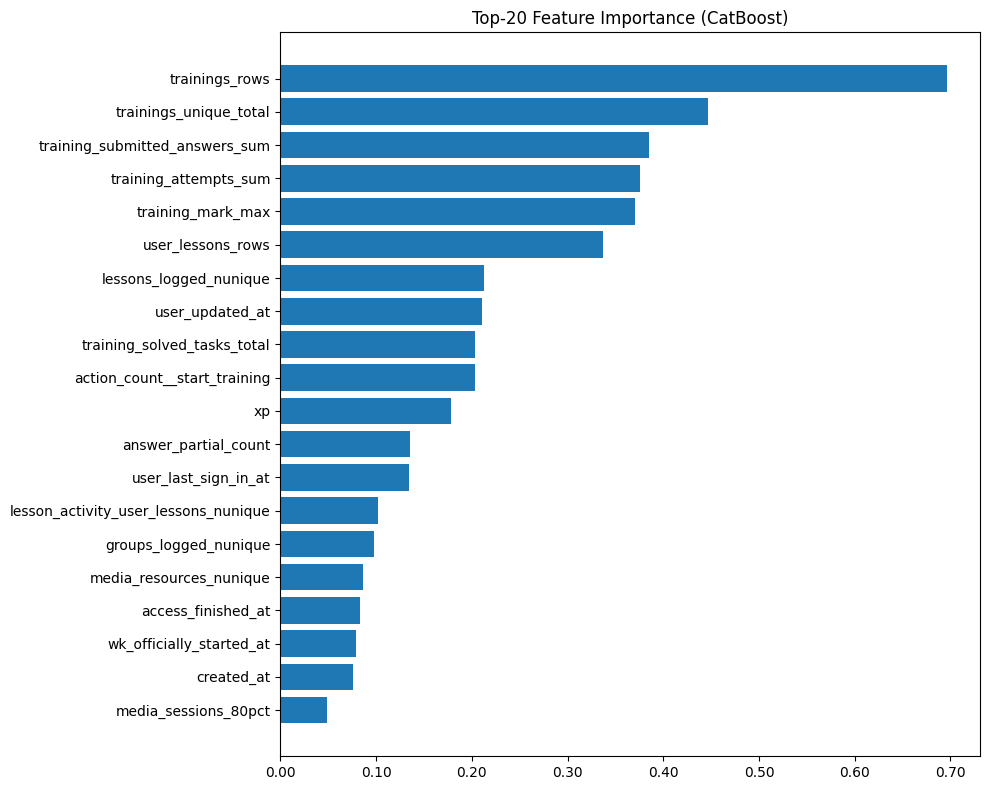

In [141]:
feature_names = X_test.columns

fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(fi['feature'], fi['importance'])
plt.gca().invert_yaxis()

plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.title("Top-20 Feature Importance (CatBoost)")
plt.tight_layout()
plt.show()

In [142]:
# выведим classification report для теста
cb_test_pred_labels = (cb_test_pred >= 0.5).astype(int)
print(classification_report(y_test, cb_test_pred_labels))


              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       238
         1.0       1.00      1.00      1.00       748

    accuracy                           1.00       986
   macro avg       1.00      0.99      1.00       986
weighted avg       1.00      1.00      1.00       986



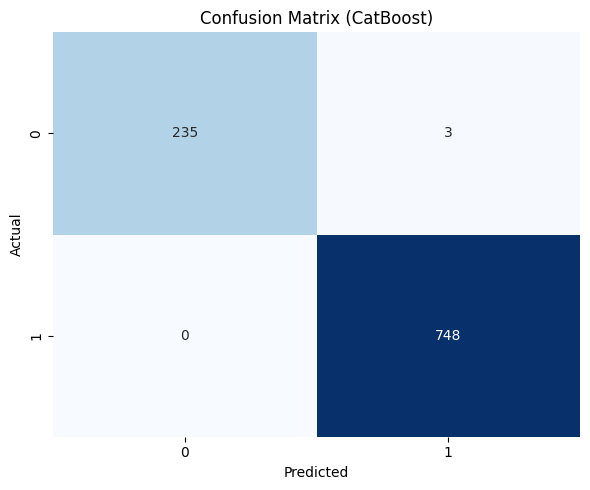

In [143]:
# Выведим confusion matrix для теста
cm = confusion_matrix(y_test, cb_test_pred_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted') 
plt.ylabel('Actual')
plt.title('Confusion Matrix (CatBoost)')
plt.tight_layout()
plt.show()

In [144]:
# Копируем данные
from sklearn.preprocessing import OrdinalEncoder


X_train_encoded = X_train.copy()
X_valid_encoded = X_val.copy()
X_test_encoded = X_test.copy()

# Находим текстовые колонки
text_columns = X_train.select_dtypes(include=['object']).columns

for col in text_columns:
    X_train_encoded[col] = X_train_encoded[col].astype(str)
    X_valid_encoded[col] = X_valid_encoded[col].astype(str)
    X_test_encoded[col] = X_test_encoded[col].astype(str)

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',  # как обрабатывать новые значения
    unknown_value=-1,                     # значение для новых категорий
    encoded_missing_value=-1              # значение для пропусков
)

# Обучаем на всех данных сразу (или только на train)
encoder.fit(X_train_encoded[text_columns])

# Преобразуем все наборы данных
X_train_encoded[text_columns] = encoder.transform(X_train_encoded[text_columns])
X_valid_encoded[text_columns] = encoder.transform(X_valid_encoded[text_columns])
X_test_encoded[text_columns] = encoder.transform(X_test_encoded[text_columns])

# Теперь создаем Dataset
lgb_train = lgb.Dataset(X_train_encoded, y_train)
lgb_valid = lgb.Dataset(X_valid_encoded, y_val, reference=lgb_train)
lgb_test = lgb.Dataset(X_test_encoded, y_test, reference=lgb_train)

C:\Users\pizhu\AppData\Local\Temp\ipykernel_26756\1712200220.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = X_train.select_dtypes(include=['object']).columns


In [145]:
lgb_params = {
    # базовая логика бустинга
    'boosting_type': 'gbdt',         # классический gradient boosting decision trees
    'objective': 'binary',           # бинарная классификация
    'metric': 'auc',                 # метрика качества

    'extra_trees': True,          # случайный выбор порогов (меньше переобучение)

    'num_leaves': 31,                # число листьев (главный параметр сложности)
    'max_depth': -1,                 # ограничение глубины (-1 = без ограничения)
    'learning_rate': 0.05,           # шаг обучения

    'min_child_samples': 20,         # минимальное число объектов в листе
    'min_child_weight': 1e-3,        # минимальная сумма hessian в листе
    'min_split_gain': 0.0,           # минимальный прирост качества для сплита

    'subsample': 0.8,                # доля объектов для дерева
    'subsample_freq': 1,             # как часто применять subsample
    'feature_fraction': 0.8,         # доля признаков для дерева

    'scale_pos_weight': scale_pos_weight,  # балансировка классов

    'lambda_l1': 0.5,                # l1-регуляризация
    'lambda_l2': 1.0,                # l2-регуляризация

    'max_bin': 255,                  # число бинов для гистограмм
    'n_jobs': -1,                    # использовать все ядра

    'seed': 42,
    'verbosity': -1                  # отключить лишние логи
}

In [146]:
%%time
lgb_model = lgb.train(
    params=lgb_params,
    train_set=lgb_train,
    num_boost_round=2000,                         # максимум деревьев
    valid_sets=[lgb_train, lgb_valid],            # мониторинг
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),  # также добавим раннюю остановку
        lgb.log_evaluation(period=100)            # лог каждые 100 итераций
    ]
)

Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.999996	valid's auc: 0.999972
Early stopping, best iteration is:
[15]	train's auc: 0.999967	valid's auc: 0.999989
CPU times: total: 12.8 s
Wall time: 1.9 s


In [147]:
# выведим classification report для теста для LightGBM
lgb_test_pred = lgb_model.predict(X_test_encoded, num_iteration=lgb_model.best_iteration)
lgb_test_pred_labels = (lgb_test_pred >= 0.5).astype(int)
print(classification_report(y_test, lgb_test_pred_labels))  


              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98       238
         1.0       0.99      1.00      0.99       748

    accuracy                           0.99       986
   macro avg       0.99      0.98      0.99       986
weighted avg       0.99      0.99      0.99       986



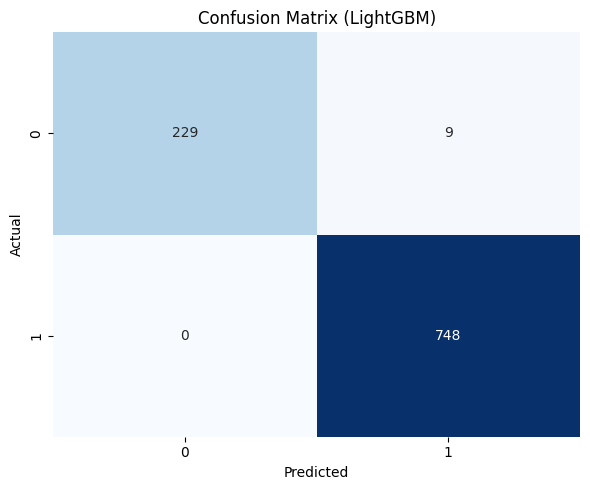

In [148]:
# Выведим confusion matrix для теста для LightGBM
cm = confusion_matrix(y_test, lgb_test_pred_labels) 
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (LightGBM)')
plt.tight_layout()
plt.show()

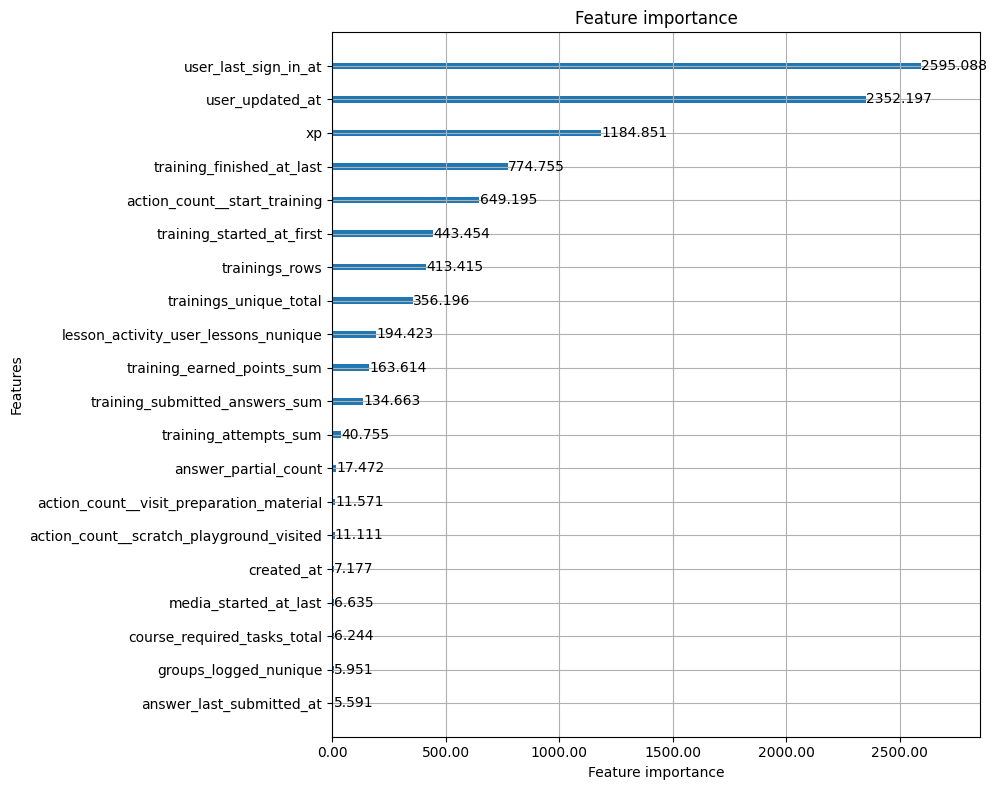

In [149]:
fig, ax = plt.subplots(figsize=(10, 8))

lgb.plot_importance(
    lgb_model,
    importance_type='gain',
    max_num_features=20,
    ax=ax
)

ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

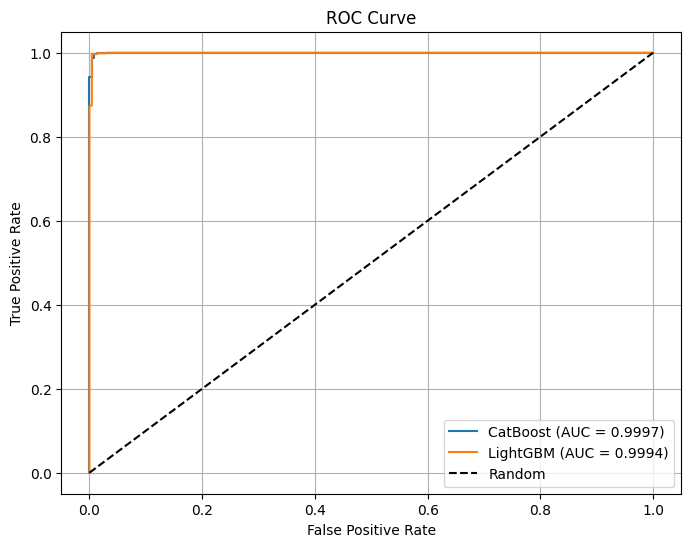

In [150]:
# ROC-AUC - CatBoost и LightGBM
from sklearn.metrics import auc, roc_curve


fpr_cb, tpr_cb, _ = roc_curve(y_test, cb_test_pred)
roc_auc_cb = auc(fpr_cb, tpr_cb)

fpr_lgb, tpr_lgb, _ = roc_curve(y_test, lgb_test_pred)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)

# Построение графика
plt.figure(figsize=(8, 6))
plt.plot(fpr_cb, tpr_cb, label=f'CatBoost (AUC = {roc_auc_cb:.4f})')
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {roc_auc_lgb:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()